In [1]:
import sys
from pathlib import Path

# Add the project root directory to Python's import path
project_root = Path.cwd().parent
sys.path.append(str(project_root))

from PIL import Image
from src.detector import ObjectDetector

In [2]:
print("Current working directory:")
print(Path.cwd())

print("\nProject root:")
print(project_root)

print("\nPython import paths:")
print(sys.path)

Current working directory:
c:\Work\mini_adas_vision\notebooks

Project root:
c:\Work\mini_adas_vision

Python import paths:
['C:\\Users\\rushi\\AppData\\Local\\Programs\\Python\\Python313\\python313.zip', 'C:\\Users\\rushi\\AppData\\Local\\Programs\\Python\\Python313\\DLLs', 'C:\\Users\\rushi\\AppData\\Local\\Programs\\Python\\Python313\\Lib', 'C:\\Users\\rushi\\AppData\\Local\\Programs\\Python\\Python313', 'c:\\Work\\mini_adas_vision\\.venv', '', 'c:\\Work\\mini_adas_vision\\.venv\\Lib\\site-packages', 'c:\\Work\\mini_adas_vision']


In [3]:
image = Image.open("../images/road.jpg")

print("Image size:", image.size)

Image size: (500, 334)


In [4]:
detector = ObjectDetector()

Loading model: facebook/detr-resnet-50
Using device: cpu


Loading weights:   0%|          | 0/530 [00:00<?, ?it/s]

[transformers] DetrForObjectDetection LOAD REPORT from: facebook/detr-resnet-50
Key                                                            | Status     |  | 
---------------------------------------------------------------+------------+--+-
model.backbone.model.layer2.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.model.layer4.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.model.layer1.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.model.layer3.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [5]:
detections = detector.detect(image)

In [6]:
print(f"Number of detections: {len(detections)}")

for detection in detections:
    print(detection)

Number of detections: 50
{'label': 'person', 'score': 0.5495909452438354, 'box': [243.3289031982422, 176.46177673339844, 251.63018798828125, 192.98162841796875]}
{'label': 'car', 'score': 0.6830475926399231, 'box': [222.99053955078125, 171.41810607910156, 233.60618591308594, 179.91470336914062]}
{'label': 'person', 'score': 0.7110489010810852, 'box': [237.0771484375, 176.21646118164062, 246.900146484375, 196.15638732910156]}
{'label': 'person', 'score': 0.8095473051071167, 'box': [419.6012268066406, 178.13890075683594, 432.9241943359375, 216.2056884765625]}
{'label': 'person', 'score': 0.5590566992759705, 'box': [39.66762161254883, 173.23582458496094, 54.56563949584961, 221.84933471679688]}
{'label': 'person', 'score': 0.7682541608810425, 'box': [409.7339782714844, 178.51080322265625, 422.407958984375, 215.01991271972656]}
{'label': 'truck', 'score': 0.7127168774604797, 'box': [344.268310546875, 171.84300231933594, 406.4440612792969, 243.4425506591797]}
{'label': 'person', 'score': 0.6

In [7]:
from src.analyzer import ADASAnalyzer

In [8]:
analyzer = ADASAnalyzer(detections)

In [9]:
analysis = analyzer.analyze()

In [10]:
print("Object counts:")
print(analysis["object_counts"])

print("\nWarnings:")

for warning in analysis["warnings"]:
    print(f"⚠ {warning}")

Object counts:
{'vehicles': 19, 'people': 28, 'bicycles': 0, 'motorcycles': 3}

Warnings:


In [11]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle


def visualize_detections(image, detections):
    """
    Draw detected objects and their bounding boxes.
    """

    fig, ax = plt.subplots(figsize=(14, 8))

    ax.imshow(image)

    for detection in detections:
        label = detection["label"]
        score = detection["score"]

        xmin, ymin, xmax, ymax = detection["box"]

        # Draw bounding box
        rectangle = Rectangle(
            (xmin, ymin),
            xmax - xmin,
            ymax - ymin,
            fill=False,
            linewidth=2
        )

        ax.add_patch(rectangle)

        # Draw label
        ax.text(
            xmin,
            ymin,
            f"{label}: {score:.2f}",
            fontsize=10,
            backgroundcolor="white"
        )

    ax.axis("off")
    plt.show()

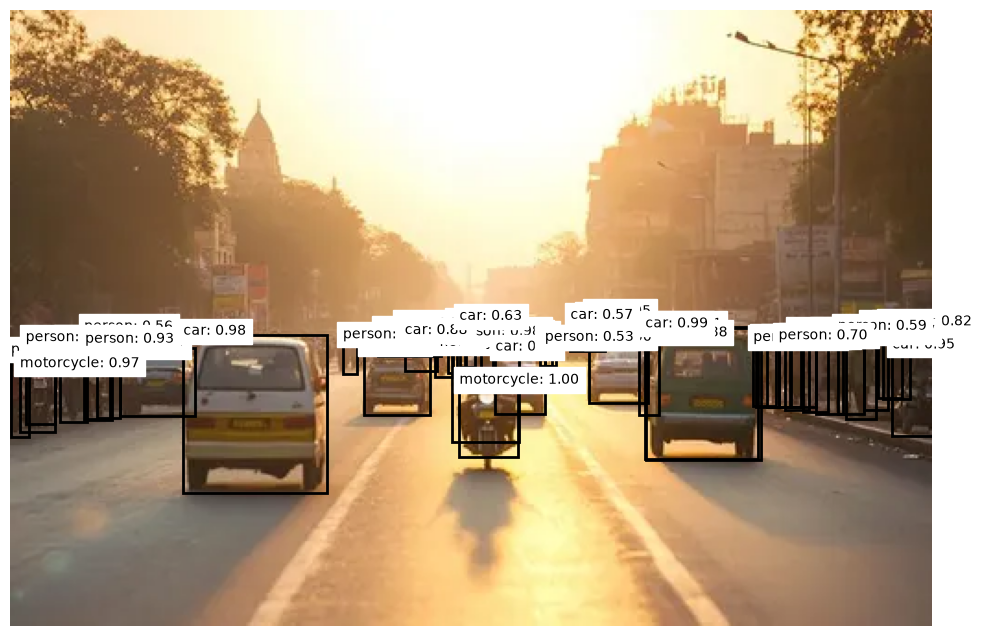

In [12]:
visualize_detections(image, detections)

In [13]:
detector = ObjectDetector(
    confidence_threshold=0.7
)

Loading model: facebook/detr-resnet-50
Using device: cpu


Loading weights:   0%|          | 0/530 [00:00<?, ?it/s]

[transformers] DetrForObjectDetection LOAD REPORT from: facebook/detr-resnet-50
Key                                                            | Status     |  | 
---------------------------------------------------------------+------------+--+-
model.backbone.model.layer2.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.model.layer4.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.model.layer1.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.model.layer3.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [14]:
detections = detector.detect(image)

In [15]:
print(f"Number of detections: {len(detections)}")

Number of detections: 35


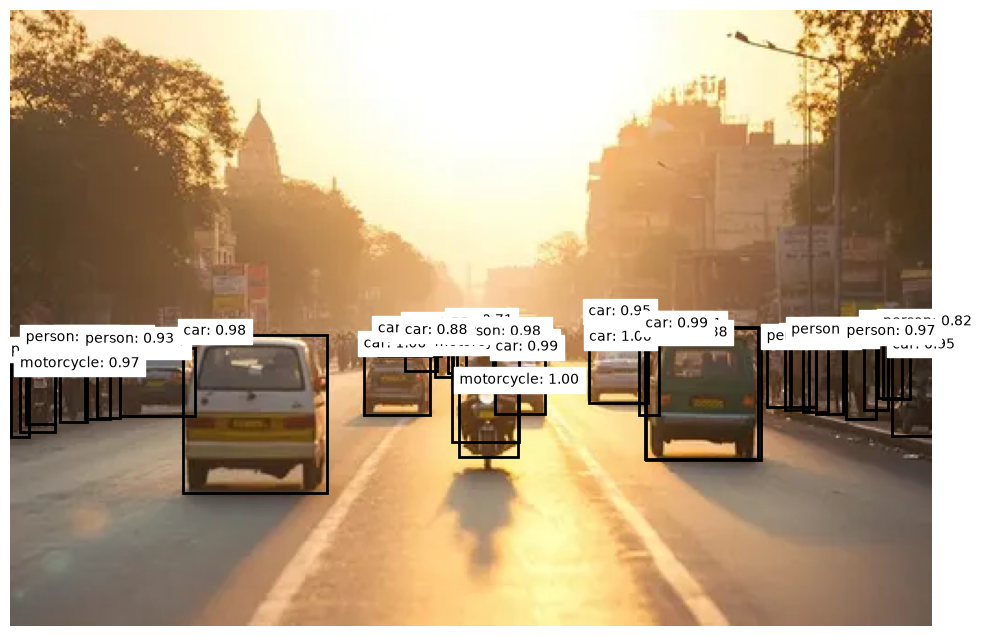

In [16]:
visualize_detections(image, detections)

In [17]:
print("Image width:", image.width)
print("Image height:", image.height)

Image width: 500
Image height: 334


In [18]:
def get_box_center(box):
    """
    Calculate the center point of a bounding box.

    box format:
        [xmin, ymin, xmax, ymax]
    """

    xmin, ymin, xmax, ymax = box

    center_x = (xmin + xmax) / 2
    center_y = (ymin + ymax) / 2

    return center_x, center_y

In [19]:
detection = detections[0]

center_x, center_y = get_box_center(
    detection["box"]
)

print("Label:", detection["label"])
print("Score:", detection["score"])
print("Box:", detection["box"])
print("Center:", center_x, center_y)

Label: person
Score: 0.7110489010810852
Box: [237.0771484375, 176.21646118164062, 246.900146484375, 196.15638732910156]
Center: 241.9886474609375 186.1864242553711


In [20]:
def get_vertical_zone(center_y, image_height):
    """
    Classify an object's vertical position.
    """

    relative_y = center_y / image_height

    if relative_y < 0.4:
        return "far"

    elif relative_y < 0.65:
        return "middle"

    else:
        return "near"

In [21]:
for detection in detections:

    center_x, center_y = get_box_center(
        detection["box"]
    )

    zone = get_vertical_zone(
        center_y,
        image.height
    )

    print(
        f"{detection['label']:12s} "
        f"score={detection['score']:.2f} "
        f"center=({center_x:.0f}, {center_y:.0f}) "
        f"zone={zone}"
    )

person       score=0.71 center=(242, 186) zone=middle
person       score=0.81 center=(426, 197) zone=middle
person       score=0.77 center=(416, 197) zone=middle
truck        score=0.71 center=(375, 208) zone=middle
car          score=0.95 center=(489, 207) zone=middle
person       score=0.76 center=(469, 194) zone=middle
car          score=0.71 center=(244, 174) zone=middle
person       score=0.86 center=(5, 208) zone=middle
motorcycle   score=0.82 center=(235, 190) zone=middle
person       score=0.84 center=(444, 197) zone=middle
car          score=0.72 center=(226, 180) zone=middle
person       score=0.82 center=(436, 197) zone=middle
person       score=0.78 center=(430, 195) zone=middle
car          score=1.00 center=(209, 201) zone=middle
person       score=0.96 center=(34, 201) zone=middle
person       score=0.94 center=(16, 202) zone=middle
car          score=0.95 center=(328, 173) zone=middle
car          score=0.95 center=(209, 181) zone=middle
person       score=0.70 center=(

In [22]:
def is_in_central_region(
        center_x,
        image_width,
        left_ratio=0.2,
        right_ratio=0.8
):
    """
    Determine whether an object lies within
    the central region of the image.
    """

    left_boundary = image_width * left_ratio
    right_boundary = image_width * right_ratio

    return left_boundary <= center_x <= right_boundary

In [23]:
for detection in detections:

    center_x, center_y = get_box_center(
        detection["box"]
    )

    central = is_in_central_region(
        center_x,
        image.width
    )

    print(
        f"{detection['label']:12s} "
        f"center_x={center_x:.0f} "
        f"central={central}"
    )

person       center_x=242 central=True
person       center_x=426 central=False
person       center_x=416 central=False
truck        center_x=375 central=True
car          center_x=489 central=False
person       center_x=469 central=False
car          center_x=244 central=True
person       center_x=5 central=False
motorcycle   center_x=235 central=True
person       center_x=444 central=False
car          center_x=226 central=True
person       center_x=436 central=False
person       center_x=430 central=False
car          center_x=209 central=True
person       center_x=34 central=False
person       center_x=16 central=False
car          center_x=328 central=True
car          center_x=209 central=True
person       center_x=53 central=False
car          center_x=80 central=False
person       center_x=252 central=True
car          center_x=132 central=True
person       center_x=477 central=False
person       center_x=480 central=False
person       center_x=257 central=True
person       cent

In [24]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle


def visualize_zones(image):
    """
    Display the image with our spatial ADAS zones.
    """

    width = image.width
    height = image.height

    fig, ax = plt.subplots(figsize=(14, 8))

    ax.imshow(image)

    # Central region
    left = width * 0.2
    right = width * 0.8

    central_width = right - left

    central_region = Rectangle(
        (left, 0),
        central_width,
        height,
        fill=False,
        linewidth=3
    )

    ax.add_patch(central_region)

    # Horizontal zone boundaries
    middle_y = height * 0.4
    near_y = height * 0.65

    ax.axhline(
        middle_y,
        linewidth=2
    )

    ax.axhline(
        near_y,
        linewidth=2
    )

    # Labels
    ax.text(
        width * 0.02,
        height * 0.2,
        "FAR",
        fontsize=14,
        backgroundcolor="white"
    )

    ax.text(
        width * 0.02,
        height * 0.52,
        "MIDDLE",
        fontsize=14,
        backgroundcolor="white"
    )

    ax.text(
        width * 0.02,
        height * 0.82,
        "NEAR",
        fontsize=14,
        backgroundcolor="white"
    )

    ax.text(
        width * 0.45,
        height * 0.05,
        "CENTRAL REGION",
        fontsize=14,
        backgroundcolor="white"
    )

    ax.axis("off")

    plt.show()

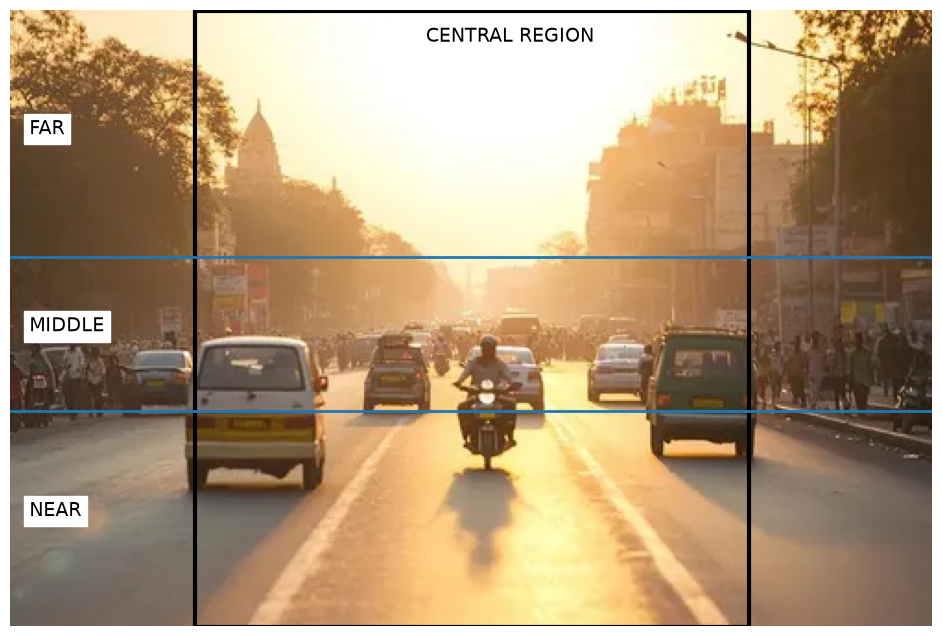

In [25]:
visualize_zones(image)

In [26]:
from matplotlib.patches import Polygon


def visualize_danger_zone(image):
    """
    Display an approximate ego-lane danger zone.
    """

    width = image.width
    height = image.height

    # Relative coordinates
    points = [
        (0.42 * width, 0.40 * height),
        (0.58 * width, 0.40 * height),
        (0.90 * width, 1.00 * height),
        (0.10 * width, 1.00 * height),
    ]

    fig, ax = plt.subplots(figsize=(14, 8))

    ax.imshow(image)

    polygon = Polygon(
        points,
        closed=True,
        fill=False,
        linewidth=3
    )

    ax.add_patch(polygon)

    ax.text(
        0.45 * width,
        0.45 * height,
        "EGO-LANE\nDANGER ZONE",
        fontsize=14,
        backgroundcolor="white"
    )

    ax.axis("off")

    plt.show()

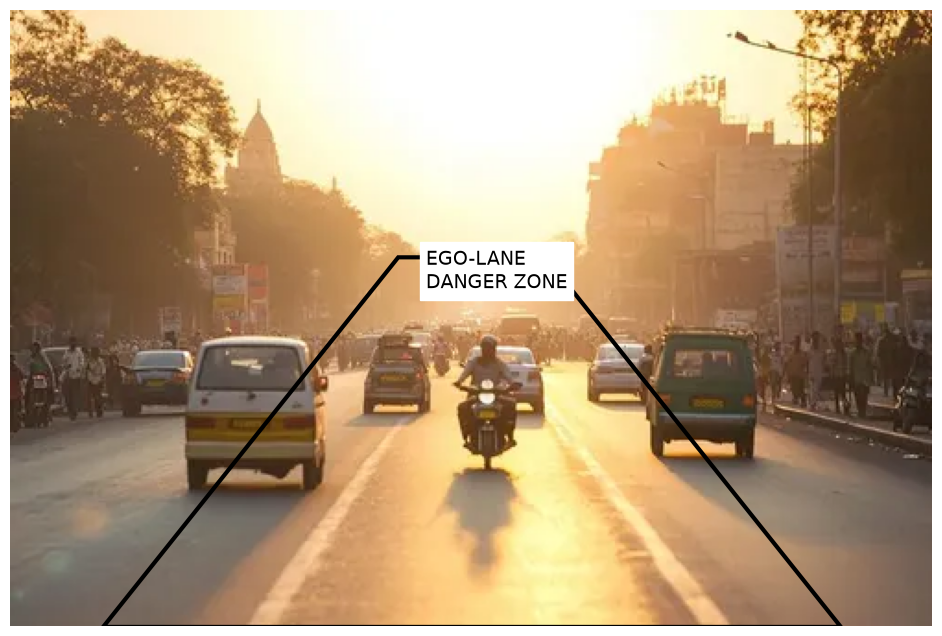

In [27]:
visualize_danger_zone(image)

In [28]:
from matplotlib.path import Path

In [29]:
def is_inside_danger_zone(
    center_x,
    center_y,
    image_width,
    image_height
):
    """
    Check whether an object's center lies
    inside the approximate ego-lane corridor.
    """

    points = [
        (0.42 * image_width, 0.40 * image_height),
        (0.58 * image_width, 0.40 * image_height),
        (0.90 * image_width, 1.00 * image_height),
        (0.10 * image_width, 1.00 * image_height),
    ]

    polygon = Path(points)

    return polygon.contains_point(
        (center_x, center_y)
    )

In [30]:
for detection in detections:

    center_x, center_y = get_box_center(
        detection["box"]
    )

    inside = is_inside_danger_zone(
        center_x,
        center_y,
        image.width,
        image.height
    )

    print(
        f"{detection['label']:12s} "
        f"score={detection['score']:.2f} "
        f"center=({center_x:.0f}, {center_y:.0f}) "
        f"inside_zone={inside}"
    )

person       score=0.71 center=(242, 186) inside_zone=True
person       score=0.81 center=(426, 197) inside_zone=False
person       score=0.77 center=(416, 197) inside_zone=False
truck        score=0.71 center=(375, 208) inside_zone=False
car          score=0.95 center=(489, 207) inside_zone=False
person       score=0.76 center=(469, 194) inside_zone=False
car          score=0.71 center=(244, 174) inside_zone=True
person       score=0.86 center=(5, 208) inside_zone=False
motorcycle   score=0.82 center=(235, 190) inside_zone=True
person       score=0.84 center=(444, 197) inside_zone=False
car          score=0.72 center=(226, 180) inside_zone=True
person       score=0.82 center=(436, 197) inside_zone=False
person       score=0.78 center=(430, 195) inside_zone=False
car          score=1.00 center=(209, 201) inside_zone=True
person       score=0.96 center=(34, 201) inside_zone=False
person       score=0.94 center=(16, 202) inside_zone=False
car          score=0.95 center=(328, 173) inside_

In [31]:
def visualize_spatial_detections(
    image,
    detections
):
    """
    Visualize detections together with
    the approximate ego-lane corridor.
    """

    width = image.width
    height = image.height

    zone_points = [
        (0.42 * width, 0.40 * height),
        (0.58 * width, 0.40 * height),
        (0.90 * width, 1.00 * height),
        (0.10 * width, 1.00 * height),
    ]

    polygon_path = Path(zone_points)

    fig, ax = plt.subplots(figsize=(14, 8))

    ax.imshow(image)

    # Draw danger zone
    polygon = Polygon(
        zone_points,
        closed=True,
        fill=False,
        linewidth=3
    )

    ax.add_patch(polygon)

    # Draw detections
    for detection in detections:

        label = detection["label"]
        score = detection["score"]

        xmin, ymin, xmax, ymax = detection["box"]

        center_x, center_y = get_box_center(
            detection["box"]
        )

        inside = polygon_path.contains_point(
            (center_x, center_y)
        )

        rectangle = Rectangle(
            (xmin, ymin),
            xmax - xmin,
            ymax - ymin,
            fill=False,
            linewidth=2
        )

        ax.add_patch(rectangle)

        ax.scatter(
            center_x,
            center_y,
            s=30
        )

        status = "ZONE" if inside else "OUTSIDE"

        ax.text(
            xmin,
            ymin,
            f"{label}: {score:.2f}\n{status}",
            fontsize=8,
            backgroundcolor="white"
        )

    ax.axis("off")

    plt.show()

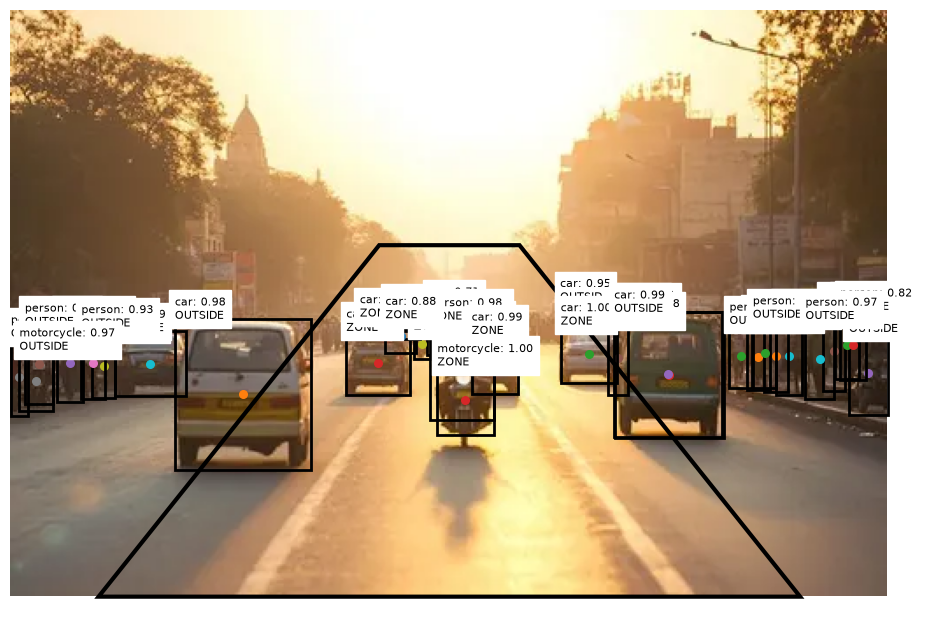

In [32]:
visualize_spatial_detections(
    image,
    detections
)

In [33]:
def calculate_risk_score(
    detection,
    inside_zone,
    vertical_zone
):
    """
    Calculate a simple heuristic ADAS risk score.

    This is NOT a collision probability.
    It is an application-level priority score.
    """

    label = detection["label"]
    confidence = detection["score"]

    # Object importance
    object_weights = {
        "person": 1.0,
        "motorcycle": 1.0,
        "bicycle": 1.0,
        "car": 0.7,
        "truck": 0.7,
        "bus": 0.7
    }

    object_weight = object_weights.get(
        label,
        0.5
    )

    # Spatial importance
    if inside_zone:
        spatial_weight = 1.0
    else:
        spatial_weight = 0.2

    # Distance approximation based on vertical position
    vertical_weights = {
        "far": 0.3,
        "middle": 0.6,
        "near": 1.0
    }

    vertical_weight = vertical_weights[
        vertical_zone
    ]

    # Final heuristic score
    risk_score = (
        object_weight
        * spatial_weight
        * vertical_weight
        * confidence
    )

    return risk_score

In [34]:
def get_risk_level(score):
    """
    Convert numerical risk score into
    a simple risk category.
    """

    if score >= 0.6:
        return "HIGH"

    elif score >= 0.3:
        return "MEDIUM"

    else:
        return "LOW"

In [35]:
for detection in detections:

    center_x, center_y = get_box_center(
        detection["box"]
    )

    vertical_zone = get_vertical_zone(
        center_y,
        image.height
    )

    inside_zone = is_inside_danger_zone(
        center_x,
        center_y,
        image.width,
        image.height
    )

    risk_score = calculate_risk_score(
        detection,
        inside_zone,
        vertical_zone
    )

    risk_level = get_risk_level(
        risk_score
    )

    print(
        f"{detection['label']:12s} "
        f"confidence={detection['score']:.2f} "
        f"zone={vertical_zone:6s} "
        f"inside={str(inside_zone):5s} "
        f"risk={risk_score:.2f} "
        f"{risk_level}"
    )

person       confidence=0.71 zone=middle inside=True  risk=0.43 MEDIUM
person       confidence=0.81 zone=middle inside=False risk=0.10 LOW
person       confidence=0.77 zone=middle inside=False risk=0.09 LOW
truck        confidence=0.71 zone=middle inside=False risk=0.06 LOW
car          confidence=0.95 zone=middle inside=False risk=0.08 LOW
person       confidence=0.76 zone=middle inside=False risk=0.09 LOW
car          confidence=0.71 zone=middle inside=True  risk=0.30 LOW
person       confidence=0.86 zone=middle inside=False risk=0.10 LOW
motorcycle   confidence=0.82 zone=middle inside=True  risk=0.49 MEDIUM
person       confidence=0.84 zone=middle inside=False risk=0.10 LOW
car          confidence=0.72 zone=middle inside=True  risk=0.30 MEDIUM
person       confidence=0.82 zone=middle inside=False risk=0.10 LOW
person       confidence=0.78 zone=middle inside=False risk=0.09 LOW
car          confidence=1.00 zone=middle inside=True  risk=0.42 MEDIUM
person       confidence=0.96 zone=mi

In [36]:
def calculate_iou(box_a, box_b):
    """
    Calculate Intersection over Union (IoU)
    between two bounding boxes.

    Box format:
        [xmin, ymin, xmax, ymax]
    """

    ax1, ay1, ax2, ay2 = box_a
    bx1, by1, bx2, by2 = box_b

    # Intersection rectangle
    intersection_x1 = max(ax1, bx1)
    intersection_y1 = max(ay1, by1)

    intersection_x2 = min(ax2, bx2)
    intersection_y2 = min(ay2, by2)

    # Intersection dimensions
    intersection_width = max(
        0,
        intersection_x2 - intersection_x1
    )

    intersection_height = max(
        0,
        intersection_y2 - intersection_y1
    )

    intersection_area = (
        intersection_width
        * intersection_height
    )

    # Individual box areas
    area_a = (
        (ax2 - ax1)
        * (ay2 - ay1)
    )

    area_b = (
        (bx2 - bx1)
        * (by2 - by1)
    )

    # Union
    union_area = (
        area_a
        + area_b
        - intersection_area
    )

    if union_area == 0:
        return 0.0

    return intersection_area / union_area

In [37]:
box_a = [100, 100, 200, 200]
box_b = [300, 300, 400, 400]

iou = calculate_iou(
    box_a,
    box_b
)

print("IoU:", iou)

IoU: 0.0


In [38]:
box_a = [100, 100, 200, 200]
box_b = [150, 150, 250, 250]

iou = calculate_iou(
    box_a,
    box_b
)

print("IoU:", round(iou, 3))

IoU: 0.143


In [39]:
for i in range(len(detections)):

    for j in range(i + 1, len(detections)):

        detection_a = detections[i]
        detection_b = detections[j]

        # Only compare objects of the same class
        if detection_a["label"] != detection_b["label"]:
            continue

        iou = calculate_iou(
            detection_a["box"],
            detection_b["box"]
        )

        if iou > 0.3:

            print(
                f"{detection_a['label']:12s} "
                f"det_{i:02d} vs det_{j:02d} "
                f"IoU={iou:.3f} "
                f"scores="
                f"{detection_a['score']:.2f}/"
                f"{detection_b['score']:.2f}"
            )

person       det_01 vs det_12 IoU=0.535 scores=0.81/0.78
person       det_09 vs det_11 IoU=0.308 scores=0.84/0.82
car          det_10 vs det_30 IoU=0.366 scores=0.72/0.88
person       det_11 vs det_12 IoU=0.330 scores=0.82/0.78
person       det_18 vs det_26 IoU=0.358 scores=0.70/0.93
person       det_22 vs det_23 IoU=0.597 scores=0.81/0.82


In [40]:
motorcycles = [
    detection
    for detection in detections
    if detection["label"] == "motorcycle"
]

print(
    f"Motorcycle detections: "
    f"{len(motorcycles)}"
)

for index, motorcycle in enumerate(motorcycles):

    print(
        f"\nMotorcycle {index + 1}"
    )

    print(
        "Confidence:",
        round(motorcycle["score"], 3)
    )

    print(
        "Box:",
        [
            round(value, 1)
            for value in motorcycle["box"]
        ]
    )

    print(
        "Center:",
        [
            round(value, 1)
            for value in get_box_center(
                motorcycle["box"]
            )
        ]
    )

Motorcycle detections: 3

Motorcycle 1
Confidence: 0.818
Box: [229.8, 181.7, 239.5, 198.7]
Center: [234.6, 190.2]

Motorcycle 2
Confidence: 0.968
Box: [4.9, 193.2, 23.8, 228.4]
Center: [14.3, 210.8]

Motorcycle 3
Confidence: 0.997
Box: [243.2, 202.1, 275.2, 241.9]
Center: [259.2, 222.0]


In [41]:
for i in range(len(motorcycles)):

    for j in range(i + 1, len(motorcycles)):

        iou = calculate_iou(
            motorcycles[i]["box"],
            motorcycles[j]["box"]
        )

        print(
            f"Motorcycle {i + 1} vs "
            f"{j + 1}: "
            f"IoU={iou:.3f}"
        )

Motorcycle 1 vs 2: IoU=0.000
Motorcycle 1 vs 3: IoU=0.000
Motorcycle 2 vs 3: IoU=0.000


In [42]:
def get_box_bottom_center(box):
    """
    Calculate the bottom-center point of a bounding box.

    Box format:
        [xmin, ymin, xmax, ymax]
    """

    xmin, ymin, xmax, ymax = box

    bottom_center_x = (xmin + xmax) / 2
    bottom_center_y = ymax

    return bottom_center_x, bottom_center_y

In [43]:
for detection in detections:

    center_x, center_y = get_box_center(
        detection["box"]
    )

    bottom_x, bottom_y = get_box_bottom_center(
        detection["box"]
    )

    print(
        f"{detection['label']:12s} "
        f"center=({center_x:.1f}, {center_y:.1f}) "
        f"bottom=({bottom_x:.1f}, {bottom_y:.1f})"
    )

person       center=(242.0, 186.2) bottom=(242.0, 196.2)
person       center=(426.3, 197.2) bottom=(426.3, 216.2)
person       center=(416.1, 196.8) bottom=(416.1, 215.0)
truck        center=(375.4, 207.6) bottom=(375.4, 243.4)
car          center=(488.9, 206.6) bottom=(488.9, 230.2)
person       center=(469.2, 193.7) bottom=(469.2, 216.5)
car          center=(244.1, 174.4) bottom=(244.1, 178.9)
person       center=(4.9, 208.5) bottom=(4.9, 231.2)
motorcycle   center=(234.6, 190.2) bottom=(234.6, 198.7)
person       center=(443.6, 196.9) bottom=(443.6, 218.8)
car          center=(226.0, 180.4) bottom=(226.0, 187.0)
person       center=(436.3, 196.9) bottom=(436.3, 217.5)
person       center=(429.7, 194.9) bottom=(429.7, 214.9)
car          center=(209.3, 200.7) bottom=(209.3, 218.9)
person       center=(33.9, 200.9) bottom=(33.9, 222.8)
person       center=(16.1, 201.5) bottom=(16.1, 224.0)
car          center=(327.7, 173.3) bottom=(327.7, 181.6)
car          center=(209.4, 180.6) bott

In [44]:
for detection in detections:

    bottom_x, bottom_y = get_box_bottom_center(
        detection["box"]
    )

    inside = is_inside_danger_zone(
        bottom_x,
        bottom_y,
        image.width,
        image.height
    )

    print(
        f"{detection['label']:12s} "
        f"bottom=({bottom_x:.1f}, {bottom_y:.1f}) "
        f"inside_zone={inside}"
    )

person       bottom=(242.0, 196.2) inside_zone=True
person       bottom=(426.3, 216.2) inside_zone=False
person       bottom=(416.1, 215.0) inside_zone=False
truck        bottom=(375.4, 243.4) inside_zone=True
car          bottom=(488.9, 230.2) inside_zone=False
person       bottom=(469.2, 216.5) inside_zone=False
car          bottom=(244.1, 178.9) inside_zone=True
person       bottom=(4.9, 231.2) inside_zone=False
motorcycle   bottom=(234.6, 198.7) inside_zone=True
person       bottom=(443.6, 218.8) inside_zone=False
car          bottom=(226.0, 187.0) inside_zone=True
person       bottom=(436.3, 217.5) inside_zone=False
person       bottom=(429.7, 214.9) inside_zone=False
car          bottom=(209.3, 218.9) inside_zone=True
person       bottom=(33.9, 222.8) inside_zone=False
person       bottom=(16.1, 224.0) inside_zone=False
car          bottom=(327.7, 181.6) inside_zone=True
car          bottom=(209.4, 186.9) inside_zone=True
person       bottom=(52.9, 220.9) inside_zone=False
car   

In [45]:
def visualize_bottom_centers(
    image,
    detections
):
    """
    Display detections with their bottom-center points
    and ego-lane corridor.
    """

    width = image.width
    height = image.height

    zone_points = [
        (0.42 * width, 0.40 * height),
        (0.58 * width, 0.40 * height),
        (0.90 * width, 1.00 * height),
        (0.10 * width, 1.00 * height),
    ]

    polygon = Path(zone_points)

    fig, ax = plt.subplots(figsize=(14, 8))

    ax.imshow(image)

    # Draw ego-lane
    zone_polygon = Polygon(
        zone_points,
        closed=True,
        fill=False,
        linewidth=3
    )

    ax.add_patch(zone_polygon)

    for detection in detections:

        bottom_x, bottom_y = get_box_bottom_center(
            detection["box"]
        )

        inside = polygon.contains_point(
            (bottom_x, bottom_y)
        )

        xmin, ymin, xmax, ymax = detection["box"]

        # Bounding box
        rectangle = Rectangle(
            (xmin, ymin),
            xmax - xmin,
            ymax - ymin,
            fill=False,
            linewidth=1
        )

        ax.add_patch(rectangle)

        # Bottom-center point
        ax.scatter(
            bottom_x,
            bottom_y,
            s=50
        )

        ax.text(
            bottom_x,
            bottom_y + 8,
            "IN" if inside else "OUT",
            fontsize=8,
            backgroundcolor="white"
        )

    ax.set_title(
        "Bottom-Center Based Ego-Lane Detection"
    )

    ax.axis("off")

    plt.show()

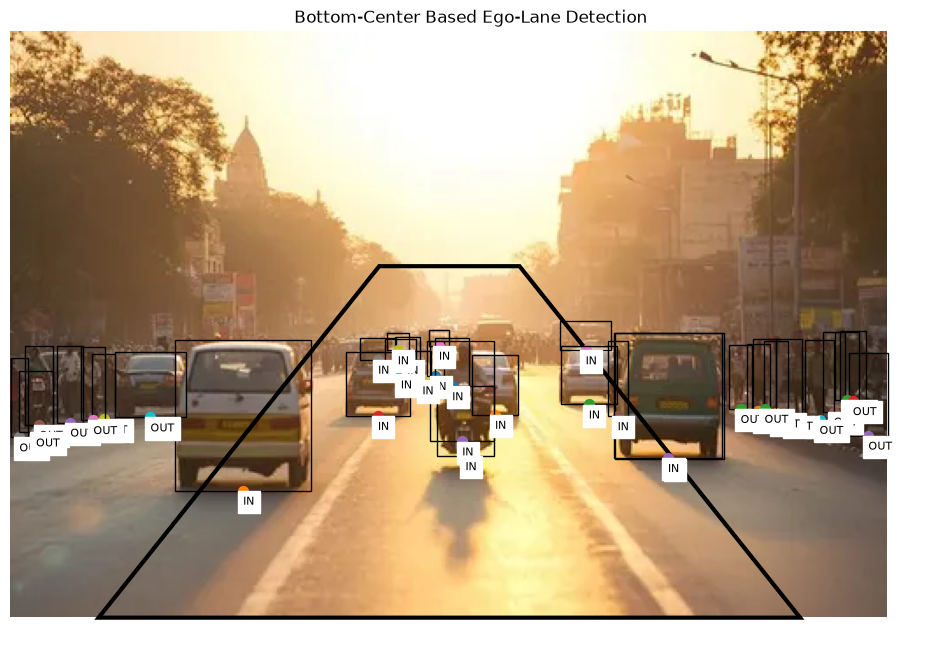

In [46]:
visualize_bottom_centers(
    image,
    detections
)

In [47]:
def get_box_dimensions(box):
    """
    Calculate bounding-box width and height.

    Box format:
        [xmin, ymin, xmax, ymax]
    """

    xmin, ymin, xmax, ymax = box

    width = xmax - xmin
    height = ymax - ymin

    return width, height

In [48]:
for detection in detections:

    width, height = get_box_dimensions(
        detection["box"]
    )

    print(
        f"{detection['label']:12s} "
        f"width={width:6.1f} "
        f"height={height:6.1f}"
    )

person       width=   9.8 height=  19.9
person       width=  13.3 height=  38.1
person       width=  12.7 height=  36.5
truck        width=  62.2 height=  71.6
car          width=  22.1 height=  47.2
person       width=  12.9 height=  45.4
car          width=  11.8 height=   9.0
person       width=   9.7 height=  45.4
motorcycle   width=   9.7 height=  17.0
person       width=  14.7 height=  43.9
car          width=  14.3 height=  13.2
person       width=  14.0 height=  41.3
person       width=  13.4 height=  40.0
car          width=  36.1 height=  36.5
person       width=  14.9 height=  43.8
person       width=  16.2 height=  45.0
car          width=  29.1 height=  16.5
car          width=  20.8 height=  12.6
person       width=  12.8 height=  37.1
car          width=  40.5 height=  37.2
person       width=  19.5 height=  27.2
car          width=  77.8 height=  86.0
person       width=  13.3 height=  38.8
person       width=  14.5 height=  40.0
person       width=  36.5 height=  57.6


In [49]:
for detection in detections:

    center_x, center_y = get_box_center(
        detection["box"]
    )

    width, height = get_box_dimensions(
        detection["box"]
    )

    normalized_height = height / image.height

    print(
        f"{detection['label']:12s} "
        f"center_y={center_y:6.1f} "
        f"height={height:6.1f} "
        f"norm_height={normalized_height:.3f}"
    )

person       center_y= 186.2 height=  19.9 norm_height=0.060
person       center_y= 197.2 height=  38.1 norm_height=0.114
person       center_y= 196.8 height=  36.5 norm_height=0.109
truck        center_y= 207.6 height=  71.6 norm_height=0.214
car          center_y= 206.6 height=  47.2 norm_height=0.141
person       center_y= 193.7 height=  45.4 norm_height=0.136
car          center_y= 174.4 height=   9.0 norm_height=0.027
person       center_y= 208.5 height=  45.4 norm_height=0.136
motorcycle   center_y= 190.2 height=  17.0 norm_height=0.051
person       center_y= 196.9 height=  43.9 norm_height=0.131
car          center_y= 180.4 height=  13.2 norm_height=0.039
person       center_y= 196.9 height=  41.3 norm_height=0.124
person       center_y= 194.9 height=  40.0 norm_height=0.120
car          center_y= 200.7 height=  36.5 norm_height=0.109
person       center_y= 200.9 height=  43.8 norm_height=0.131
person       center_y= 201.5 height=  45.0 norm_height=0.135
car          center_y= 1

In [50]:
def calculate_proximity_score(
        bottom_y,
        box_height,
        image_height
):
    """
    Estimate proximity using:
    - bottom-center vertical position
    - normalized bouding-box height

    This is NOT real-world distance.
    It is a simple image-based heuristic.
    """

    normalized_bottom_y = bottom_y / image_height
    normalized_height = box_height / image_height

    # Weighted combination
    proximity_score = (
        0.6 * normalized_bottom_y
        + 0.4 * normalized_height
    )

    return proximity_score

In [51]:
for detection in detections:

    bottom_x, bottom_y = get_box_bottom_center(
        detection["box"]
    )

    width, height = get_box_dimensions(
        detection["box"]
    )

    proximity_score = calculate_proximity_score(
        bottom_y,
        height,
        image.height
    )

    print(
        f"{detection['label']:12s} "
        f"bottom_y={bottom_y:6.1f} "
        f"height={height:6.1f} "
        f"proximity={proximity_score:.3f}"
    )

person       bottom_y= 196.2 height=  19.9 proximity=0.376
person       bottom_y= 216.2 height=  38.1 proximity=0.434
person       bottom_y= 215.0 height=  36.5 proximity=0.430
truck        bottom_y= 243.4 height=  71.6 proximity=0.523
car          bottom_y= 230.2 height=  47.2 proximity=0.470
person       bottom_y= 216.5 height=  45.4 proximity=0.443
car          bottom_y= 178.9 height=   9.0 proximity=0.332
person       bottom_y= 231.2 height=  45.4 proximity=0.470
motorcycle   bottom_y= 198.7 height=  17.0 proximity=0.377
person       bottom_y= 218.8 height=  43.9 proximity=0.446
car          bottom_y= 187.0 height=  13.2 proximity=0.352
person       bottom_y= 217.5 height=  41.3 proximity=0.440
person       bottom_y= 214.9 height=  40.0 proximity=0.434
car          bottom_y= 218.9 height=  36.5 proximity=0.437
person       bottom_y= 222.8 height=  43.8 proximity=0.453
person       bottom_y= 224.0 height=  45.0 proximity=0.456
car          bottom_y= 181.6 height=  16.5 proximity=0.3

In [52]:
proximity_results = []

for detection in detections:

    bottom_x, bottom_y = get_box_bottom_center(
        detection["box"]
    )

    width, height = get_box_dimensions(
        detection["box"]
    )

    proximity_score = calculate_proximity_score(
        bottom_y,
        height,
        image.height
    )

    proximity_results.append({
        "label": detection["label"],
        "score": detection["score"],
        "bottom_y": bottom_y,
        "height": height,
        "proximity": proximity_score
    })

proximity_results.sort(
    key=lambda x: x["proximity"],
    reverse=True
)

for result in proximity_results:
    print(
        f"{result['label']:12s} "
        f"confidence={result['score']:.2f} "
        f"bottom_y={result['bottom_y']:6.1f} "
        f"height={result['height']:6.1f} "
        f"proximity={result['proximity']:.3f}"
    )

car          confidence=0.98 bottom_y= 261.6 height=  86.0 proximity=0.573
truck        confidence=0.71 bottom_y= 243.4 height=  71.6 proximity=0.523
car          confidence=0.99 bottom_y= 243.0 height=  71.4 proximity=0.522
person       confidence=0.98 bottom_y= 233.6 height=  57.6 proximity=0.489
motorcycle   confidence=1.00 bottom_y= 241.9 height=  39.8 proximity=0.482
car          confidence=0.95 bottom_y= 230.2 height=  47.2 proximity=0.470
person       confidence=0.86 bottom_y= 231.2 height=  45.4 proximity=0.470
person       confidence=0.94 bottom_y= 224.0 height=  45.0 proximity=0.456
person       confidence=0.96 bottom_y= 222.8 height=  43.8 proximity=0.453
motorcycle   confidence=0.97 bottom_y= 228.4 height=  35.2 proximity=0.452
person       confidence=0.97 bottom_y= 221.2 height=  45.5 proximity=0.452
person       confidence=0.93 bottom_y= 221.4 height=  41.4 proximity=0.447
person       confidence=0.84 bottom_y= 218.8 height=  43.9 proximity=0.446
person       confidence=0

In [56]:
print("Analysis keys:")
print(analysis.keys())

print("\nSpatial results:")
print(analysis["spatial_results"])

print("\nType:")
print(type(analysis["spatial_results"]))

Analysis keys:
dict_keys(['object_counts', 'spatial_results', 'warnings'])

Spatial results:
None

Type:
<class 'NoneType'>


In [59]:
from PIL import Image

from src.detector import ObjectDetector
from src.analyzer import ADASAnalyzer


# Load image
image = Image.open("../images/road.jpg")


# Create detector
detector = ObjectDetector()


# Run object detection
print("Running object detection...")
detections = detector.detect(image)

print(f"Detections found: {len(detections)}")


# Create analyzer using detections
analyzer = ADASAnalyzer(detections)


# Run complete ADAS analysis
analysis = analyzer.analyze(
    image.width,
    image.height
)


# Inspect result
print("\nAnalysis keys:")
print(analysis.keys())

print("\nNumber of spatial results:")
print(len(analysis["spatial_results"]))

Loading model: facebook/detr-resnet-50
Using device: cpu


Loading weights:   0%|          | 0/530 [00:00<?, ?it/s]

[transformers] DetrForObjectDetection LOAD REPORT from: facebook/detr-resnet-50
Key                                                            | Status     |  | 
---------------------------------------------------------------+------------+--+-
model.backbone.model.layer2.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.model.layer4.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.model.layer1.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.model.layer3.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Running object detection...
Detections found: 50

Analysis keys:
dict_keys(['object_counts', 'spatial_results', 'warnings'])

Number of spatial results:
50


In [61]:
print("CAR RISK DIAGNOSTICS")
print("=" * 70)

for result in analysis["spatial_results"]:

    if result["label"] == "car":

        print(
            f"car | "
            f"confidence={result['score']:.2f} | "
            f"zone={result['vertical_zone']} | "
            f"inside={result['inside_danger_zone']} | "
            f"proximity={result['proximity']} | "
            f"risk={result['risk_score']:.3f} | "
            f"level={result['risk_level']}"
        )

CAR RISK DIAGNOSTICS
car | confidence=0.68 | zone=middle | inside=True | proximity=far | risk=0.268 | level=LOW
car | confidence=0.95 | zone=middle | inside=False | proximity=medium | risk=0.079 | level=LOW
car | confidence=0.71 | zone=middle | inside=True | proximity=far | risk=0.276 | level=LOW
car | confidence=0.72 | zone=middle | inside=True | proximity=far | risk=0.284 | level=LOW
car | confidence=0.55 | zone=middle | inside=True | proximity=far | risk=0.219 | level=LOW
car | confidence=1.00 | zone=middle | inside=True | proximity=medium | risk=0.408 | level=MEDIUM
car | confidence=0.69 | zone=middle | inside=True | proximity=far | risk=0.269 | level=LOW
car | confidence=0.95 | zone=middle | inside=True | proximity=far | risk=0.373 | level=MEDIUM
car | confidence=0.95 | zone=middle | inside=True | proximity=far | risk=0.373 | level=MEDIUM
car | confidence=0.99 | zone=middle | inside=False | proximity=medium | risk=0.081 | level=LOW
car | confidence=0.98 | zone=near | inside=True |

In [62]:
print("RISK COMPONENT ANALYSIS")
print("=" * 70)

for result in analysis["spatial_results"]:

    if result["label"] in ["car", "truck", "motorcycle", "person"]:

        print(
            f"{result['label']:12s} "
            f"confidence={result['score']:.2f} | "
            f"proximity={result['proximity']:6s} | "
            f"inside={str(result['inside_danger_zone']):5s} | "
            f"risk={result['risk_score']:.3f} | "
            f"{result['risk_level']}"
        )

RISK COMPONENT ANALYSIS
person       confidence=0.55 | proximity=far    | inside=True  | risk=0.312 | MEDIUM
car          confidence=0.68 | proximity=far    | inside=True  | risk=0.268 | LOW
person       confidence=0.71 | proximity=far    | inside=True  | risk=0.406 | MEDIUM
person       confidence=0.81 | proximity=medium | inside=False | risk=0.095 | LOW
person       confidence=0.56 | proximity=medium | inside=False | risk=0.066 | LOW
person       confidence=0.77 | proximity=medium | inside=False | risk=0.090 | LOW
truck        confidence=0.71 | proximity=near   | inside=True  | risk=0.302 | MEDIUM
person       confidence=0.65 | proximity=medium | inside=False | risk=0.076 | LOW
car          confidence=0.95 | proximity=medium | inside=False | risk=0.079 | LOW
person       confidence=0.76 | proximity=medium | inside=False | risk=0.090 | LOW
car          confidence=0.71 | proximity=far    | inside=True  | risk=0.276 | LOW
person       confidence=0.86 | proximity=medium | inside=False | 